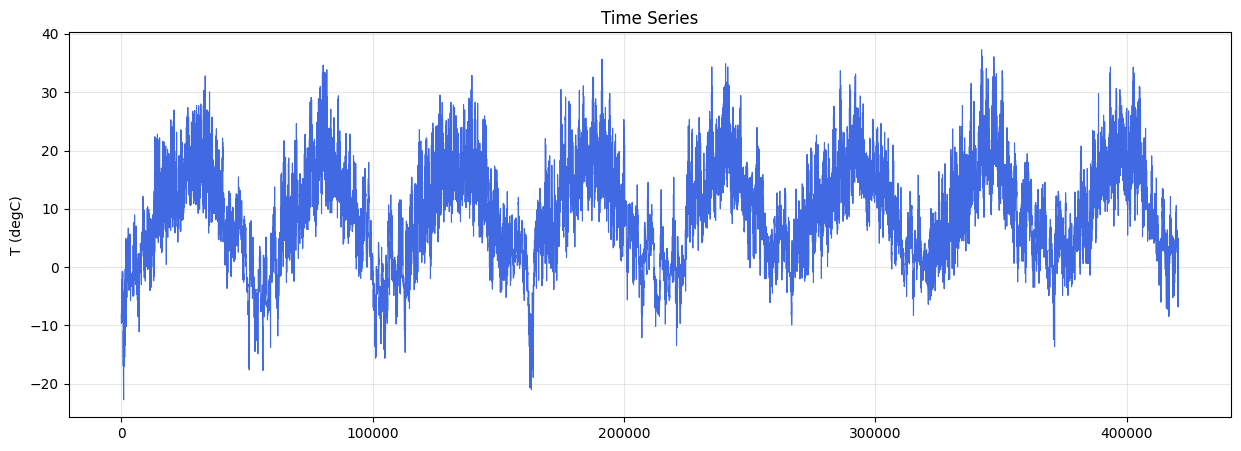

In [11]:
import pandas as pd
from utils import prepare_data, plot_time_series, plot_results
import torch.nn as nn
import numpy as np
import torch

# --- 1. CONFIGURATION ---
URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
TARGET = 'T (degC)'
FEATURES = ['p (mbar)', 'T (degC)', 'rh (%)', 'rho (g/m**3)']
SEQ_LEN = 24

# --- 2. LOAD & VISUALIZE ---
df = pd.read_csv(URL, compression='zip')[5::6] # Hourly
plot_time_series(df, TARGET)

# --- 3. PREPARE DATA ---
train_loader, test_loader, scaler = prepare_data(
    df, 
    target_col=TARGET, 
    feature_cols=FEATURES, 
    seq_length=SEQ_LEN
)

In [12]:
class DeterministicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(DeterministicLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # lstm_out shape: (batch, seq_len, hidden_dim)
        lstm_out, _ = self.lstm(x)
        # We only care about the last time step's prediction
        last_time_step = lstm_out[:, -1, :]
        return self.fc(last_time_step)

# Initialize
model = DeterministicLSTM(input_dim=len(FEATURES), hidden_dim=64, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() # Standard deterministic loss

In [13]:
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 10
BATCH_SIZE = 64


# Model, Optimizer, Criterion
model = DeterministicLSTM(input_dim=len(FEATURES), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 

# Training Loop
train_losses = []
for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        output = model(batch_x).squeeze()
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Epoch 1: 100%|██████████| 876/876 [00:07<00:00, 114.03it/s]


Epoch 1: Loss = 0.0382


Epoch 2: 100%|██████████| 876/876 [00:07<00:00, 115.39it/s]


Epoch 2: Loss = 0.0079


Epoch 3: 100%|██████████| 876/876 [00:07<00:00, 118.05it/s]


...

Epoch 8: Loss = 0.0073


Epoch 9: 100%|██████████| 876/876 [00:07<00:00, 113.22it/s]


Epoch 9: Loss = 0.0073


Epoch 10: 100%|██████████| 876/876 [00:07<00:00, 117.85it/s]

Epoch 10: Loss = 0.0072


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_deterministic(model, test_loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            output = model(batch_x).squeeze()
            all_preds.extend(output.numpy())
            all_targets.extend(batch_y.numpy())
            
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test MAE:  {mae:.4f}")
    
    return np.array(all_preds), np.array(all_targets)

preds, targets = evaluate_deterministic(model, test_loader)

Test RMSE: 0.0877
Test MAE:  0.0612


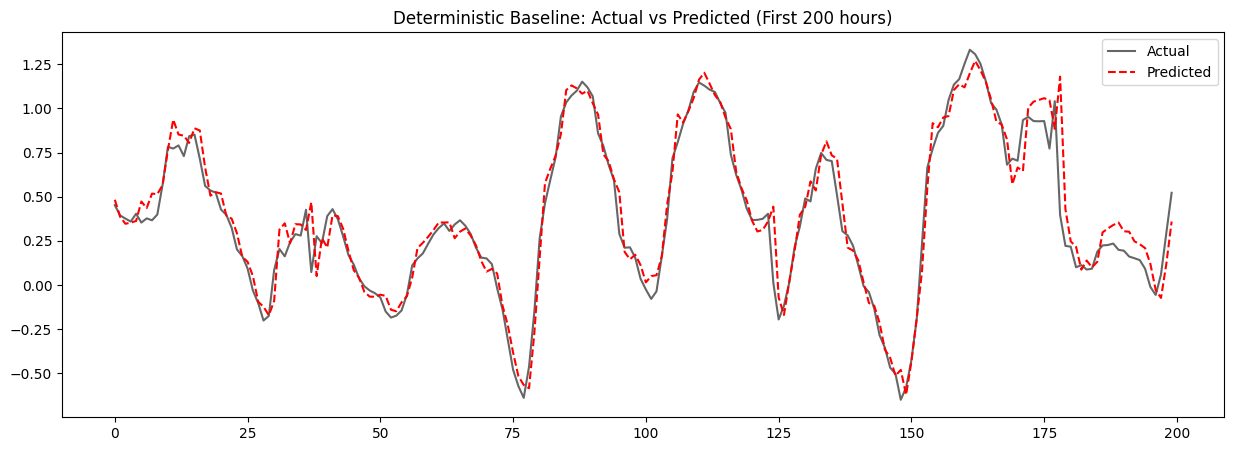

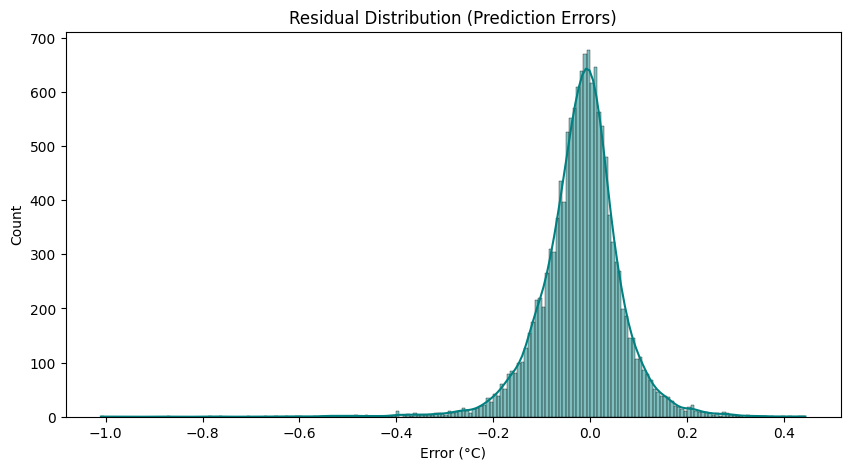

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prediction vs Actual Plot 
plt.figure(figsize=(15, 5))
plt.plot(targets[:200], label="Actual", color='black', alpha=0.6)
plt.plot(preds[:200], label="Predicted", color='red', linestyle='--')
plt.title("Deterministic Baseline: Actual vs Predicted (First 200 hours)")
plt.legend()
plt.show()

# 2. Error Distribution (Residual Plot)
errors = targets - preds
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, color='teal')
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Error (°C)")
plt.show()

In [ ]:
# multivariate forecasting